In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root
from scipy.special import ellipk
from scipy.signal import find_peaks, peak_widths
from scipy.constants import mu_0, epsilon_0

In [8]:
# Constant values and sweep parameters
N = 1001
L01 = 1.80333428e-10
L02 = 1.80333428e-10
LT = 4.33057147e-10 # Base value of the josephson junction tunable inductance
R_j = 1.55985018e+01 # resistance of the resistor
phi_ext = np.linspace(0, 2*np.pi, N) # for magnetic flux sweep
Z_0 = 50 # characteristic input impedance
#fr = 5e9
f_r = np.linspace(4.5e9, 5.5e9, N) # for frequency sweep
w_r = 2*np.pi*f_r
C_c = (5.22641116e-14) # coupling capacitance to the transmission line (not shown in the setup)

# Solves for the phase difference delta of the josephson junction in the RF SQUID
def del_sol(delta, a, phi_ext_val):
    
    lhs = delta + a * np.sin(delta)
    
    return lhs - phi_ext_val


# calculates the impedance of the coupling capacitor to the transmission line (not shown in the setup)
def c_cap(c_c, w):
    return np.array([[1,1/(1j*c_c*w)],[0,1]])

# calculates the impedance of the resonator
def tline(Z0, beta, L):
    return np.array([[np.cos(beta*L),1j*Z0*np.sin(beta*L)],[1j*(1/Z0)*np.sin(beta*L),np.cos(beta*L)]])


def Z_L(L_01, L_02, L_T, d, w, R):
    ZL01 = 1j*w*L_01
    ZL02 = 1j*w*L_02
    ZLT = 1j*w*L_T/np.cos(d)
    ZL02R = (1/ZL02 + 1/R)**(-1)
    ZSQUID = (1/ZL01 + 1/(ZLT + ZL02R))**(-1)
    
    return ZSQUID

def Z_tot(ZL, Z0, beta, l, c_c, w):
    x = beta*l
    Z_c = 1/(1j*w*c_c)
    return (Z0*((ZL + 1j*Z0*np.tan(x))/(Z0 + 1j*ZL*np.tan(x)))) + Z_c

def branch(Z):
    return np.array([[1,0], [1/Z, 1]])
    
#calculates the ABCD matrix
def ABCD(M1, M2, M3):
    full_M = M1 @ M2 @ M3 
    
    return full_M
#Calculates the S21 parameter
def S21(A, B, C, D, Z0):
    return 2/(A + B/Z0 + C*Z0 + D)

In [205]:
x = np.array([[1,2],[3,4]])
y = np.zeros((2,2, N))
x.shape
w_r[500]

np.float64(31415926535.89793)

In [12]:
def calc_cpw_param_set(
    center_width: float, gap_width: float, substrate_r: float, metal_thickness: float
):
    a = center_width / 2
    b = center_width / 2 + gap_width
    d = metal_thickness / (2 * np.pi)

    u1 = (
        a
        + d / 2
        + 3 / 2 * np.log(2) * d
        - d / 2 * np.log(d / a)
        + d / 2 * np.log((b - a) / (a + b))
    )
    u2 = (
        b
        - d / 2
        - 3 / 2 * np.log(2) * d
        + d / 2 * np.log(d / a)
        + d / 2 * np.log((b - a) / (a + b))
    )
    k1 = u1 / u2
    k2 = np.sqrt(1 - k1**2)
    c = 2 * epsilon_0 * ellipk(k1) / ellipk(k2) * (1 + substrate_r)

    d = d/2
    u1 = a+d/2+3/2*np.log(2)*d-d/2*np.log(d/a)+d/2*np.log((b-a)/(a+b))
    u2 = b-d/2-3/2*np.log(2)*d+d/2*np.log(d/a)+d/2*np.log((b-a)/(a+b))
    k1 = u1/u2
    k2 = np.sqrt(1-k1**2)
    l = mu_0/4*ellipk(k2)/ellipk(k1)

    lambda_eff = 50e-9  # m, effective field penetration depth
    k = a/b
    g_ctr = 1/(4*a*ellipk(k)**2*(1-k)**2) * \
        (np.pi+np.log(4*np.pi*a/metal_thickness)-k*np.log((1+k)/(1-k)))
    g_gnd = 1/(4*a*ellipk(k)**2*(1-k)**2) * \
        (np.pi+np.log(4*np.pi*b/metal_thickness)-k*np.log((1+k)/(1-k)))
    g = g_ctr+g_gnd
    l_ki = g*mu_0*lambda_eff
    l_tot = l+l_ki

    return {'inductance': l_tot, 'capacitance': c}

def calc_target_length(target_frequency: float, cpw_param_set: dict):
    return 1e6 / (4 * target_frequency * np.sqrt(cpw_param_set['inductance'] * cpw_param_set['capacitance']))



def calc_target_frequency(target_length: float, cpw_param_set: dict):
    return 1e6 / (4 * target_length * np.sqrt(cpw_param_set['inductance'] * cpw_param_set['capacitance']))



resonator_widths = [7, 10, 7]
#################################3

res_cpw_param_set = calc_cpw_param_set(
    center_width= resonator_widths[1]*1e-6, 
    gap_width=resonator_widths[0]*1e-6, 
    substrate_r=11.6, 
    metal_thickness=200e-9
)

l = calc_target_length(5.5e9, res_cpw_param_set)
f = calc_target_frequency(5122.618693762872, res_cpw_param_set)
l_f = l/1e6
L_l = 4.84721309e-07 #res_cpw_param_set['inductance']
C_l = 1.29424392e-10 #res_cpw_param_set['capacitance']


In [65]:
(35/17117)*1000

2.044750832505696

In [13]:
TL1 = 2e-3 # first part of the transmission line
TL2 = 15e-3 # second part of the transmission line
I1 = np.eye(2)
I2 = np.eye(2)
RL = l_f
# storage arrays
delta_sols = np.zeros(N)
delta_sols[0] = phi_ext[0]
ZL_vals = np.zeros((N,N), dtype = complex)
#ZL_1_vals = np.zeros(N, dtype = complex)
#ZL_2_vals = np.zeros(N, dtype = complex)
#ZC_vals = np.zeros((2,2,N),  dtype = complex)
#Z_tline_vals_1 = np.zeros((2,2,N),  dtype = complex)
#Z_tline_vals_2 = np.zeros((2,2,N),  dtype = complex)
Z_tot_vals = np.zeros((N,N), dtype = complex)
Z_branch_vals = np.zeros((2,2,N,N), dtype = complex)
fullM_vals = np.zeros((2,2,N,N), dtype = complex)
beta_vals = np.zeros(N)
#Res = np.array([[1,0],[1/R_j,1]])
S21_vals = np.zeros((N,N), dtype = complex)

# for loop for calculating the phase difference for each flux
for k in range(1, N):
    d0 = delta_sols[k-1]
    L_f = ((L01+L02)/LT)
    sol = root(del_sol, d0, args=(L_f, phi_ext[k]))
    delta_sols[k] = sol.x[0]
        
# for loop to calculate S21 for each flux and frequency value
for i in range(N):
    beta_vals[i] = w_r[i] * np.sqrt(L_l*C_l)
    #ZC_vals[:, :, i] = c_cap(C_c, w_r[i])
    #Z_tline_vals_1[:, :, i] = tline(Z_0, beta_vals[i], TL1)
    #Z_tline_vals_2[:, :, i] = tline(Z_0, beta_vals[i], TL2)
    for j in range(N):  
        ZL_vals[i, j] = Z_L(L01, L02, LT, delta_sols[j], w_r[i], R_j)
        Z_tot_vals[i, j] = Z_tot(ZL_vals[i, j], Z_0, beta_vals[i], RL, C_c, w_r[i])
        Z_branch_vals[:, :, i, j] = branch(Z_tot_vals[i,j])
        #fullM_vals[:, :, i, j] = ABCD(Z_tline_vals_1[:, :, i], Z_branch_vals[:, :, i, j], Z_tline_vals_2[:, :, i])
        fullM_vals[:, :, i, j] = ABCD(I1, Z_branch_vals[:, :, i, j], I2)
        S21_vals[i, j] = S21(fullM_vals[0, 0, i, j], fullM_vals[0, 1, i, j], fullM_vals[1, 0, i, j], fullM_vals[1, 1, i, j], Z_0)

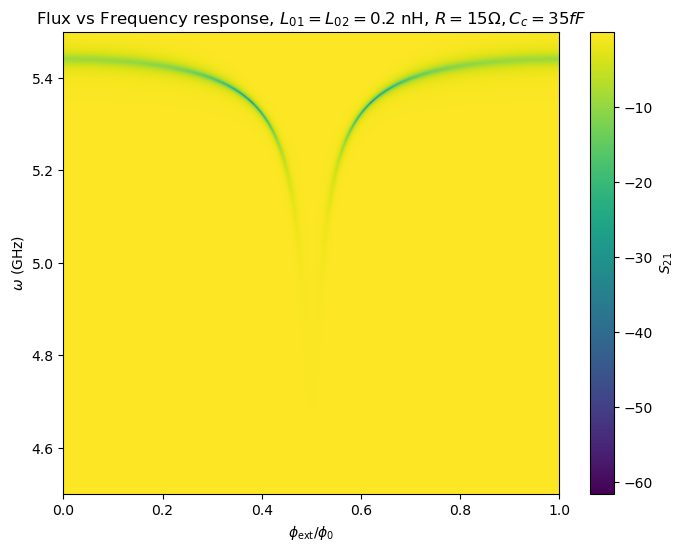

In [14]:
plt.figure(figsize=(8, 6))
plt.imshow(20*np.log10(np.abs(S21_vals)), extent = [0, 1, 4.5, 5.5], origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(label=r'$S_{21}$')
plt.xlabel(r'$\phi_{\rm ext} / \phi_0$')
plt.ylabel(r'$\omega$ (GHz)')
plt.title(r'Flux vs Frequency response, $L_{01} = L_{02} = 0.2$ nH, $R = 15 \Omega, C_c = 35 fF$')
plt.show()

In [15]:
x = 20*np.log10(np.abs(S21_vals[:, 0:500]))
y = 20*np.log10(np.abs(S21_vals[:, 500:1000]))
idx_flat = np.argmin(x)                # index in flattened array
idx_flat_2 = np.argmin(y)
i_max, j_max = np.unravel_index(idx_flat, x.shape)  # 2D indices
i_max_2, j_max_2 = np.unravel_index(idx_flat_2, y.shape)
#max_value = x[i_max, j_max]
i_max, j_max, i_max_2, j_max_2, C_c

(np.int64(847), np.int64(381), np.int64(847), np.int64(119), 5.22641116e-14)

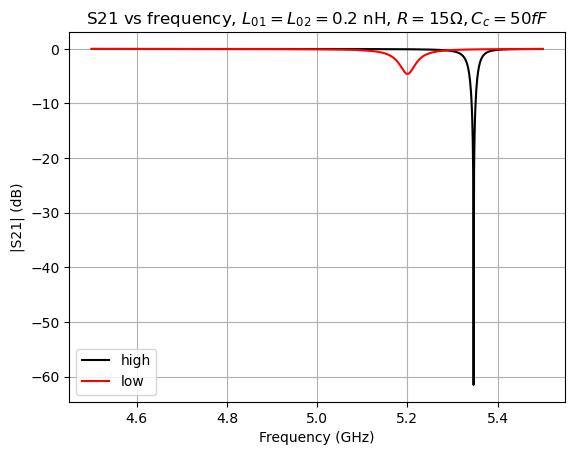

In [16]:
#j0 = np.argmin(np.abs(phi_ext - np.pi))
S21_zero_flux = S21_vals[:, j_max]  # shape (N,)
S21_shallow_flux = S21_vals[:, j_max+70] 
freq = w_r/(2*np.pi)  # your frequency array in Hz

plt.figure()
plt.plot(freq*1e-9, 20*np.log10(np.abs(S21_zero_flux)), 'k', label = 'high')
plt.plot(freq*1e-9, 20*np.log10(np.abs(S21_shallow_flux)), 'r', label = 'low')
plt.xlabel('Frequency (GHz)')
#plt.xlabel(r'$\phi_{\rm ext}/\phi_{0}$')
plt.ylabel('|S21| (dB)')
plt.title(r'S21 vs frequency, $L_{01} = L_{02} = 0.2$ nH, $R = 15 \Omega, C_c = 50 fF$')
plt.legend()
plt.grid(True)
#x = np.abs(S21_vals[


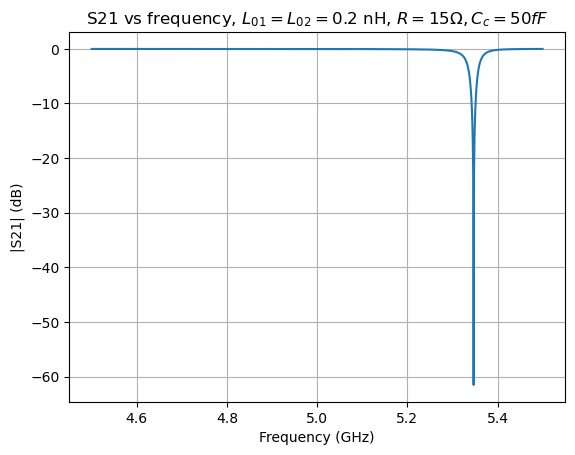

In [17]:
S21_shallow_flux = S21_vals[:, j_max]  # shape (N,)
freq = w_r/(2*np.pi)  # your frequency array in Hz

plt.figure()
plt.plot(freq*1e-9, 20*np.log10(np.abs(S21_shallow_flux)))
plt.xlabel('Frequency (GHz)')
#plt.xlabel(r'$\phi_{\rm ext}/\phi_{0}$')
plt.ylabel('|S21| (dB)')
plt.title(r'S21 vs frequency, $L_{01} = L_{02} = 0.2$ nH, $R = 15 \Omega, C_c = 50 fF$')
plt.grid(True)

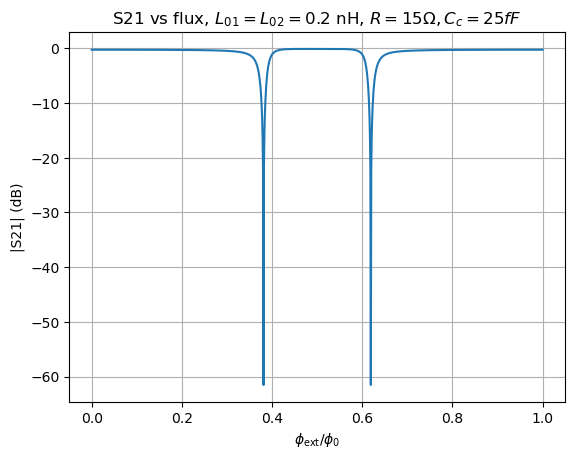

In [18]:
S21_zero_flux = S21_vals[i_max, :]  # shape (N,)
freq = w_r/(2*np.pi)  # your frequency array in Hz

plt.figure()
plt.plot(phi_ext/(2*np.pi), 20*np.log10(np.abs(S21_zero_flux)))
plt.xlabel(r'$\phi_{\rm ext} / \phi_0$')
#plt.xlabel(r'$\phi_{\rm ext}/\phi_{0}$')
plt.ylabel('|S21| (dB)')
plt.title(r'S21 vs flux, $L_{01} = L_{02} = 0.2$ nH, $R = 15 \Omega, C_c = 25 fF$')
plt.grid(True)

In [19]:
from scipy.optimize import curve_fit
def lorentzian_dip_power(f, f0, Q_L, baseline, Q_e_inv):
    """
    Fit model for |S21|^2 in terms of Q factors directly.
    Q_e_inv = 1/Q_e (easier to fit as a free parameter)
    """
    depth_amplitude = Q_L * Q_e_inv          # = Q_L / Q_e
    lorentz = depth_amplitude / (1 + 4 * Q_L**2 * ((f - f0)/f0)**2)
    # |S21|^2 = baseline * |1 - lorentz|^2
    return baseline * (1 - lorentz)**2


def calculate_q_factors(freq, S21_vals):

    # Ensure freq is a flat 1D array
    #freq = np.asarray(freq).flatten()
    n_flux = S21_vals.shape[1]
    
    q_loaded = np.zeros(n_flux)
    q_internal = np.zeros(n_flux)
    q_external = np.zeros(n_flux)
    f0_fits = np.zeros(n_flux)
    
    for i in range(n_flux):
        power = np.abs(S21_vals[:, i])**2
        
        baseline_guess = np.max(power)
        min_idx = np.argmin(power)
        f0_guess = freq[min_idx]
        S21_min = np.sqrt(power[min_idx] / baseline_guess)
        
        # Estimate df (FWHM) by finding points below the half-depth
        half_max = baseline_guess - (baseline_guess - power[min_idx]) / 2.0
        below_half = np.where(power < half_max)[0]
        
        df_guess = freq[below_half[-1]] - freq[below_half[0]]

        Q_L_guess = f0_guess/df_guess
        
        dip = np.clip(1.0-S21_min, 1e-6, 2.0)
        Qe_inv_guess = dip/Q_L_guess
                 
        p0 = [f0_guess, Q_L_guess, baseline_guess, Qe_inv_guess]
        
        popt, _ = curve_fit(lorentzian_dip_power, freq, power,
                            p0=p0, maxfev=10000)
        f0_fit, Q_L_fit, _, Qe_inv_fit = popt
        Q_L_fit = np.abs(Q_L_fit)
        Q_e_fit = 1.0 / np.abs(Qe_inv_fit)
        
        Q_i_fit = 1.0 / (1.0/Q_L_fit - 1.0/Q_e_fit)

        q_loaded[i]   = Q_L_fit
        q_external[i] = Q_e_fit
        q_internal[i] = Q_i_fit
        f0_fits[i]    = f0_fit

    return q_loaded, q_internal, q_external, f0_fits


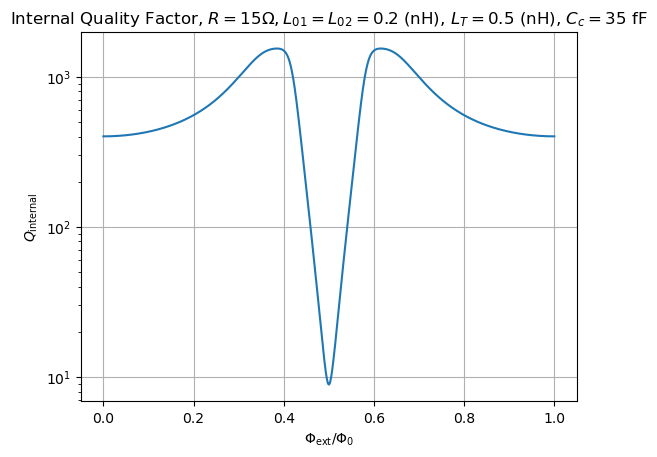

In [20]:
q_L, q_i, q_e, f0_array = calculate_q_factors(freq, S21_vals)
plt.semilogy(phi_ext/(2*np.pi), q_i)
plt.xlabel(r'$\Phi_{\rm ext}/\Phi_0$')
plt.ylabel(r'$Q_{\rm internal}$')
plt.title(r"Internal Quality Factor, $R = 15\Omega, L_{01} = L_{02} = 0.2$ (nH), $L_T = 0.5$ (nH), $C_c = 35$ fF")
plt.grid(True)
#plt.legend()
plt.show()

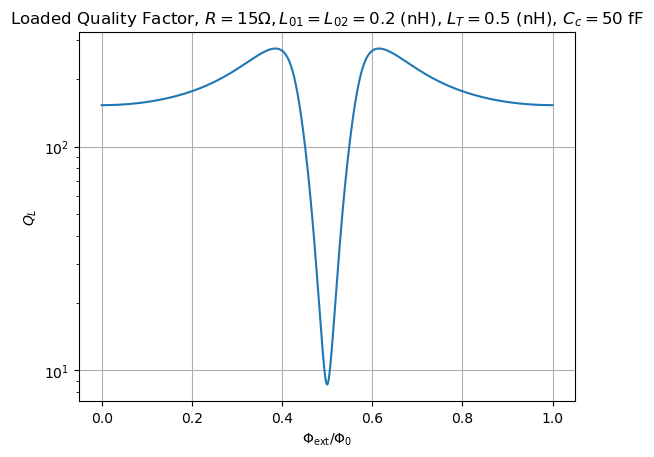

(np.float64(-116.58740821146617),
 np.float64(5.348517220423187),
 np.float64(8.63891198887566))

In [21]:
plt.semilogy(phi_ext/(2*np.pi), q_L)
plt.xlabel(r'$\Phi_{\rm ext}/\Phi_0$')
plt.ylabel(r'$Q_{L}$')
plt.title(r"Loaded Quality Factor, $R = 15\Omega, L_{01} = L_{02} = 0.2$ (nH), $L_T = 0.5$ (nH), $C_c = 50$ fF")
plt.grid(True)
#plt.legend()
plt.show()
Gamma_10 = (f0_array[379]/q_L[np.argmin(q_L)])
P_p = 1 * 6.626 * 10**(-34) * f0_array[379] * Gamma_10
10*np.log10(P_p*1000), f0_array[379]/1e9, np.min(q_L)

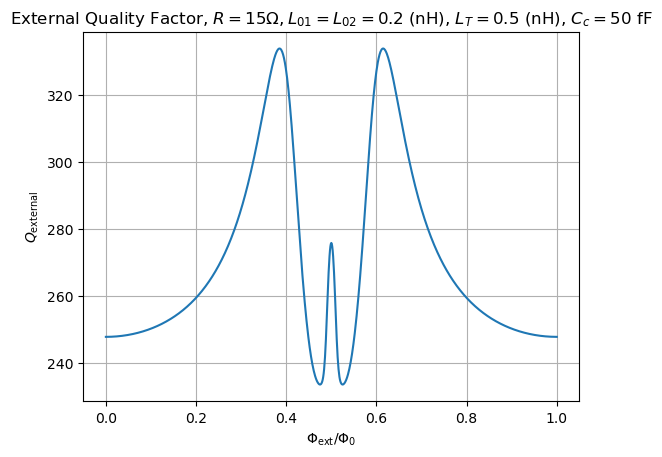

In [22]:
plt.plot(phi_ext/(2*np.pi), q_e)
plt.xlabel(r'$\Phi_{\rm ext}/\Phi_0$')
plt.ylabel(r'$Q_{\rm external}$')
plt.title(r"External Quality Factor, $R = 15\Omega, L_{01} = L_{02} = 0.2$ (nH), $L_T = 0.5$ (nH), $C_c = 50$ fF")
plt.grid(True)
#plt.legend()
plt.show()

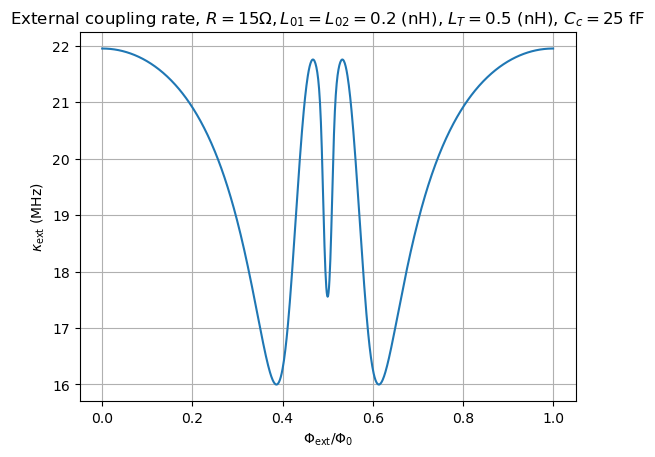

In [23]:
plt.plot(phi_ext/(2*np.pi), ((f0_array)/(q_e))/1e6)
plt.xlabel(r'$\Phi_{\rm ext}/\Phi_0$')
plt.ylabel(r'$\kappa_{\rm ext}$ (MHz)')
plt.title(r"External coupling rate, $R = 15\Omega, L_{01} = L_{02} = 0.2$ (nH), $L_T = 0.5$ (nH), $C_c = 25$ fF")
plt.grid(True)
#plt.legend()
plt.show()

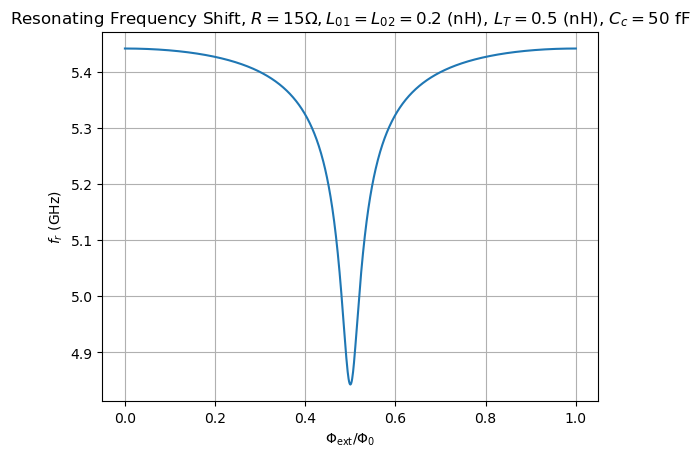

In [24]:
plt.plot(phi_ext/(2*np.pi), f0_array/1e9, label = r'$R = 20\Omega$')
plt.xlabel(r'$\Phi_{\rm ext}/\Phi_0$')
plt.ylabel(r'$f_r$ (GHz)')
plt.title(r"Resonating Frequency Shift, $R = 15\Omega, L_{01} = L_{02} = 0.2$ (nH), $L_T = 0.5$ (nH), $C_c = 50$ fF")
plt.grid(True)
plt.show()

In [38]:
L01 = 1.80333428e-10
L02 = 1.80333428e-10
LT = 4.33057147e-10
R_vals = np.linspace(5, 50, 10)
N_R = len(R_vals)
C_c = 5.22641116e-14
delta_sols_R = np.zeros((N))
delta_sols_R[0] = phi_ext[0]
ZL_vals_R = np.zeros((N,N,N_R), dtype = complex)
phi_ext = np.linspace(0, 2*np.pi, N)
f_r = np.linspace(4.5e9, 5.5e9, N) # for frequency sweep
w_r = 2*np.pi*f_r
Z_tot_vals_R = np.zeros((N,N,N_R), dtype = complex)
Z_branch_vals_R = np.zeros((2,2,N,N,N_R), dtype = complex)
fullM_vals_R = np.zeros((2,2,N,N,N_R), dtype = complex)
beta_vals_R = np.zeros(N)
#Res = np.array([[1,0],[1/R_j,1]])
S21_vals_R = np.zeros((N,N,N_R), dtype = complex)

# for loop for calculating the phase difference for each flux and frequency
for k in range(1, N):
    d0 = delta_sols_R[k-1]
    L_f = ((L01+L02)/LT)
    sol = root(del_sol, d0, args=(L_f, phi_ext[k]))
    delta_sols_R[k] = sol.x[0]
        
# for loop to calculate S21 for each flux and frequency value
for i in range(N):
    beta_vals_R[i] = w_r[i] * np.sqrt(L_l*C_l)
    #ZC_vals[:, :, i] = c_cap(C_c, w_r[i])
    #Z_tline_vals_1[:, :, i] = tline(Z_0, beta_vals[i], TL1)
    #Z_tline_vals_2[:, :, i] = tline(Z_0, beta_vals[i], TL2)
    for j in range(N):
        for k in range(N_R):
            ZL_vals_R[i, j, k] = Z_L(L01, L02, LT, delta_sols_R[j], w_r[i], R_vals[k])
            Z_tot_vals_R[i, j, k] = Z_tot(ZL_vals_R[i, j, k], Z_0, beta_vals_R[i], RL, C_c, w_r[i])
            Z_branch_vals_R[:, :, i, j, k] = branch(Z_tot_vals_R[i,j, k])
            #fullM_vals[:, :, i, j] = ABCD(Z_tline_vals_1[:, :, i], Z_branch_vals[:, :, i, j], Z_tline_vals_2[:, :, i])
            fullM_vals_R[:, :, i, j, k] = ABCD(I1, Z_branch_vals_R[:, :, i, j, k], I2)
            S21_vals_R[i, j, k] = S21(fullM_vals_R[0, 0, i, j, k], fullM_vals_R[0, 1, i, j, k], fullM_vals_R[1, 0, i, j, k], fullM_vals_R[1, 1, i, j, k], Z_0)

In [39]:
q_loaded_array_R = np.zeros((N,N_R))
q_external_array_R = np.zeros((N,N_R))
q_internal_array_R = np.zeros((N,N_R))
f0_array_R = np.zeros((N,N_R))

for i in range(N_R):
    q_loaded_array_R[:, i], q_internal_array_R[:, i], q_external_array_R[:, i], f0_array_R[:, i] =  calculate_q_factors(f_r, S21_vals_R[:, :, i])


<>:2: SyntaxWarning: invalid escape sequence '\O'
<>:2: SyntaxWarning: invalid escape sequence '\O'
C:\Users\chowdhf4\AppData\Local\Temp\ipykernel_15572\812947000.py:2: SyntaxWarning: invalid escape sequence '\O'
  plt.plot(phi_ext/(2*np.pi), f0_array_R[:,i], label = f'$R = {R_vals[i]} \Omega$')


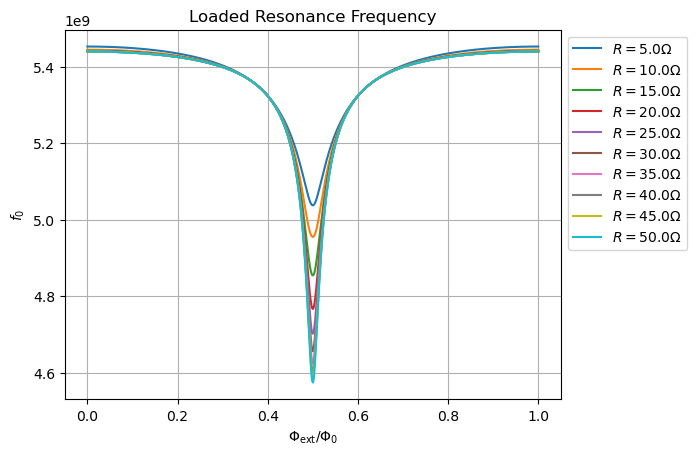

In [41]:
for i in range(len(R_vals)):
    plt.plot(phi_ext/(2*np.pi), f0_array_R[:,i], label = f'$R = {R_vals[i]} \Omega$')
    
plt.xlabel(r'$\Phi_{\rm ext}/\Phi_0$')
plt.ylabel(r'$f_0$')
plt.title(r"Loaded Resonance Frequency")
plt.grid(True)
plt.legend(loc = 'upper left', bbox_to_anchor=(1, 1))
plt.show()

<>:2: SyntaxWarning: invalid escape sequence '\O'
<>:2: SyntaxWarning: invalid escape sequence '\O'
C:\Users\chowdhf4\AppData\Local\Temp\ipykernel_15572\419392590.py:2: SyntaxWarning: invalid escape sequence '\O'
  plt.plot(phi_ext/(2*np.pi), q_loaded_array_R[:,i], label = f'$R = {R_vals[i]} \Omega$')


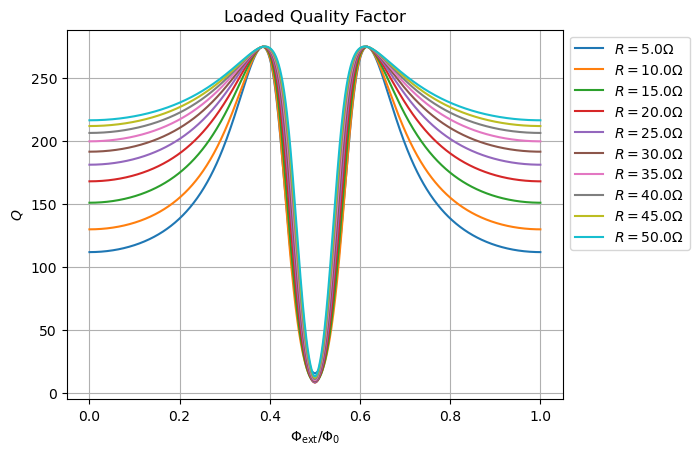

In [42]:
for i in range(len(R_vals)):
    plt.plot(phi_ext/(2*np.pi), q_loaded_array_R[:,i], label = f'$R = {R_vals[i]} \Omega$')
    
plt.xlabel(r'$\Phi_{\rm ext}/\Phi_0$')
plt.ylabel(r'$Q$')
plt.title(r"Loaded Quality Factor")
plt.grid(True)
plt.legend(loc = 'upper left', bbox_to_anchor=(1, 1))
plt.show()

In [43]:
# storage arrays
N = 1001
L01 = 1.80333428e-10
L02 = 1.80333428e-10
LT_vals = np.linspace(0.4e-9, 0.6e-9, 10)
N_L = len(LT_vals)
C_c = 5.22641116e-14
R_j = 1.55985018e+01
delta_sols_LT = np.zeros((N, N_L))
delta_sols_LT[0, :] = phi_ext[0]
ZL_vals_LT = np.zeros((N,N,N_L), dtype = complex)
phi_ext = np.linspace(0, 2*np.pi, N)
f_r = np.linspace(4e9, 5.6e9, N) # for frequency sweep
w_r = 2*np.pi*f_r
Z_tot_vals_LT = np.zeros((N,N,N_L), dtype = complex)
Z_branch_vals_LT = np.zeros((2,2,N,N,N_L), dtype = complex)
fullM_vals_LT = np.zeros((2,2,N,N,N_L), dtype = complex)
beta_vals_LT = np.zeros(N)
#Res = np.array([[1,0],[1/R_j,1]])
S21_vals_LT = np.zeros((N,N,N_L), dtype = complex)

# for loop for calculating the phase difference for each flux and frequency
for k in range(1, N):
    for l in range(N_L):
        d0 = delta_sols_LT[k-1, l]
        L_f = ((L01+L02)/LT_vals[l])
        sol = root(del_sol, d0, args=(L_f, phi_ext[k]))
        delta_sols_LT[k, l] = sol.x[0]
        
# for loop to calculate S21 for each flux and frequency value
for i in range(N):
    beta_vals_LT[i] = w_r[i] * np.sqrt(L_l*C_l)
    #ZC_vals[:, :, i] = c_cap(C_c, w_r[i])
    #Z_tline_vals_1[:, :, i] = tline(Z_0, beta_vals[i], TL1)
    #Z_tline_vals_2[:, :, i] = tline(Z_0, beta_vals[i], TL2)
    for j in range(N):
        for k in range(N_L):
            ZL_vals_LT[i, j, k] = Z_L(L01, L02, LT_vals[k], delta_sols_LT[j, k], w_r[i], R_j)
            Z_tot_vals_LT[i, j, k] = Z_tot(ZL_vals_LT[i, j, k], Z_0, beta_vals_LT[i], RL, C_c, w_r[i])
            Z_branch_vals_LT[:, :, i, j, k] = branch(Z_tot_vals_LT[i,j, k])
            #fullM_vals[:, :, i, j] = ABCD(Z_tline_vals_1[:, :, i], Z_branch_vals[:, :, i, j], Z_tline_vals_2[:, :, i])
            fullM_vals_LT[:, :, i, j, k] = ABCD(I1, Z_branch_vals_LT[:, :, i, j, k], I2)
            S21_vals_LT[i, j, k] = S21(fullM_vals_LT[0, 0, i, j, k], fullM_vals_LT[0, 1, i, j, k], fullM_vals_LT[1, 0, i, j, k], fullM_vals_LT[1, 1, i, j, k], Z_0)

In [44]:
q_loaded_array_LT = np.zeros((N,N_L))
q_external_array_LT = np.zeros((N,N_L))
q_internal_array_LT = np.zeros((N,N_L))
f0_array_LT = np.zeros((N,N_L))

for i in range(N_L):
    q_loaded_array_LT[:, i], q_internal_array_LT[:, i], q_external_array_LT[:, i], f0_array_LT[:, i] = calculate_q_factors(f_r, S21_vals_LT[:, :, i])

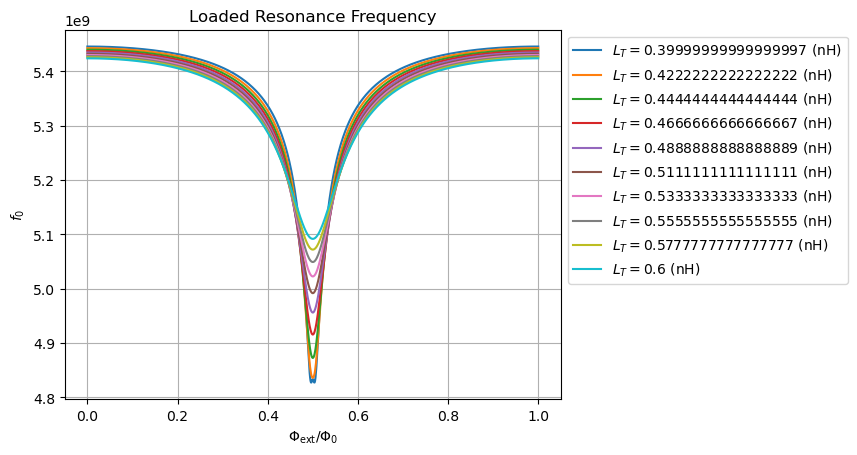

In [45]:
for i in range(len(LT_vals)):
    plt.plot(phi_ext/(2*np.pi), f0_array_LT[:,i], label = f'$L_T = {LT_vals[i]/1e-9}$ (nH)')
    
plt.xlabel(r'$\Phi_{\rm ext}/\Phi_0$')
plt.ylabel(r'$f_0$')
plt.title(r"Loaded Resonance Frequency")
plt.grid(True)
plt.legend(loc = 'upper left', bbox_to_anchor=(1, 1))
plt.show()
#np.min(q_loaded_array)

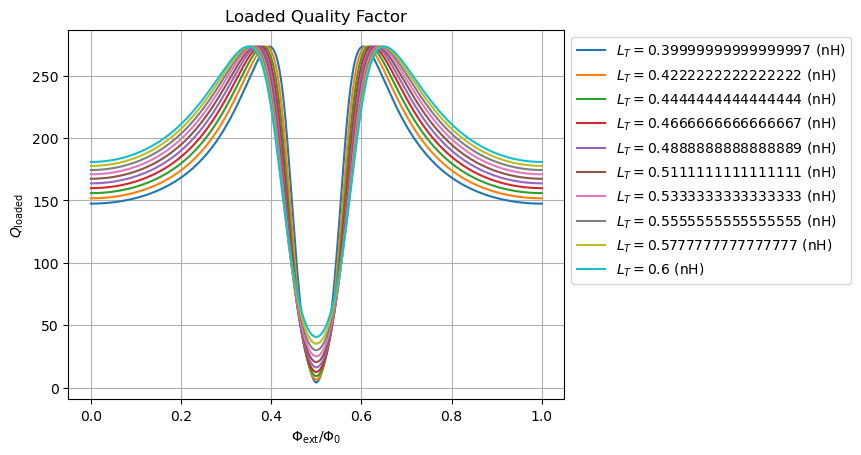

In [46]:
for i in range(len(LT_vals)):
    plt.plot(phi_ext/(2*np.pi), q_loaded_array_LT[:,i], label = f'$L_T = {LT_vals[i]/1e-9}$ (nH)')
    
plt.xlabel(r'$\Phi_{\rm ext}/\Phi_0$')
plt.ylabel(r'$Q_{\rm loaded}$')
plt.title(r"Loaded Quality Factor")
plt.grid(True)
plt.legend(loc = 'upper left', bbox_to_anchor=(1, 1))
plt.show()

In [47]:
N = 1001
L01_vals = np.linspace(0.1e-9, 0.2e-9, 10)
LT = 4.33057147e-10
L02 = 1.80333428e-10
N_L1 = len(L01_vals)
C_c = 5.22641116e-14
R_j = 1.55985018e+01
delta_sols_L01 = np.zeros((N, N_L1))
delta_sols_L01[0, :] = phi_ext[0]
ZL_vals_L01 = np.zeros((N,N,N_L1), dtype = complex)
phi_ext = np.linspace(0, 2*np.pi, N)
f_r = np.linspace(4e9, 5.6e9, N) # for frequency sweep
w_r = 2*np.pi*f_r
Z_tot_vals_L01 = np.zeros((N,N,N_L1), dtype = complex)
Z_branch_vals_L01 = np.zeros((2,2,N,N,N_L1), dtype = complex)
fullM_vals_L01 = np.zeros((2,2,N,N,N_L1), dtype = complex)
beta_vals_L01 = np.zeros(N)
#Res = np.array([[1,0],[1/R_j,1]])
S21_vals_L01 = np.zeros((N,N,N_L1), dtype = complex)

# for loop for calculating the phase difference for each flux and frequency
for k in range(1, N):
    for l in range(N_L1):
        d0 = delta_sols_L01[k-1, l]
        L_f = ((L01_vals[l]+L02)/LT)
        sol = root(del_sol, d0, args=(L_f, phi_ext[k]))
        delta_sols_L01[k, l] = sol.x[0]
        
# for loop to calculate S21 for each flux and frequency value
for i in range(N):
    beta_vals_L01[i] = w_r[i] * np.sqrt(L_l*C_l)
    #ZC_vals[:, :, i] = c_cap(C_c, w_r[i])
    #Z_tline_vals_1[:, :, i] = tline(Z_0, beta_vals[i], TL1)
    #Z_tline_vals_2[:, :, i] = tline(Z_0, beta_vals[i], TL2)
    for j in range(N):
        for k in range(N_L1):
            ZL_vals_L01[i, j, k] = Z_L(L01_vals[k], L02, LT, delta_sols_L01[j, k], w_r[i], R_j)
            Z_tot_vals_L01[i, j, k] = Z_tot(ZL_vals_L01[i, j, k], Z_0, beta_vals_L01[i], RL, C_c, w_r[i])
            Z_branch_vals_L01[:, :, i, j, k] = branch(Z_tot_vals_L01[i,j, k])
            #fullM_vals[:, :, i, j] = ABCD(Z_tline_vals_1[:, :, i], Z_branch_vals[:, :, i, j], Z_tline_vals_2[:, :, i])
            fullM_vals_L01[:, :, i, j, k] = ABCD(I1, Z_branch_vals_L01[:, :, i, j, k], I2)
            S21_vals_L01[i, j, k] = S21(fullM_vals_L01[0, 0, i, j, k], fullM_vals_L01[0, 1, i, j, k], fullM_vals_L01[1, 0, i, j, k], fullM_vals_L01[1, 1, i, j, k], Z_0)

In [48]:
q_loaded_array_L01 = np.zeros((N,N_L1))
q_internal_array_L01 = np.zeros((N,N_L1))
q_external_array_L01 = np.zeros((N,N_L1))
f0_array_L01 = np.zeros((N,N_L1))

for i in range(N_L1):
    q_loaded_array_L01[:, i], q_internal_array_L01[:, i], q_external_array_L01[:, i], f0_array_L01[:, i] = calculate_q_factors(f_r, S21_vals_L01[:, :, i])

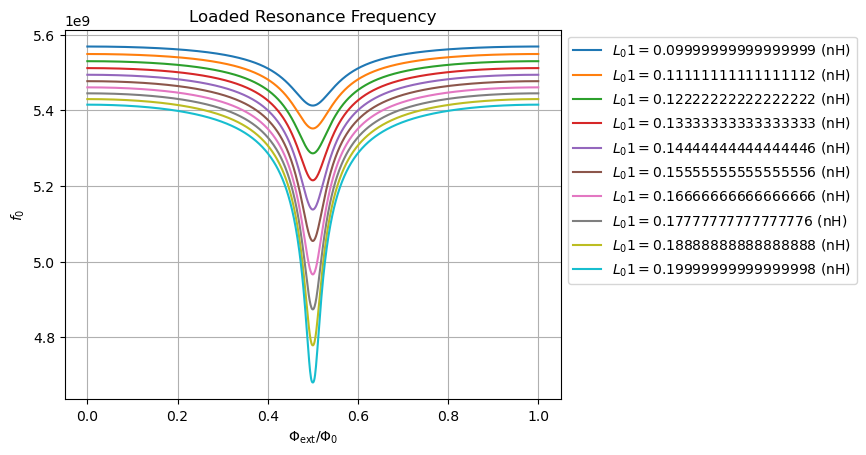

In [49]:
for i in range(len(L01_vals)):
    plt.plot(phi_ext/(2*np.pi), f0_array_L01[:,i], label = f'$L_01 = {L01_vals[i]/1e-9}$ (nH)')
    
plt.xlabel(r'$\Phi_{\rm ext}/\Phi_0$')
plt.ylabel(r'$f_0$')
plt.title(r"Loaded Resonance Frequency")
plt.grid(True)
plt.legend(loc = 'upper left', bbox_to_anchor=(1, 1))
plt.show()

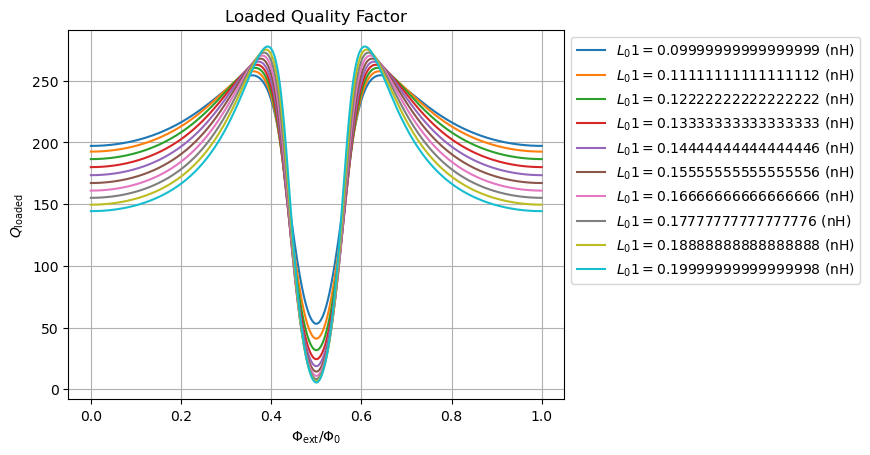

In [50]:
for i in range(len(L01_vals)):
    plt.plot(phi_ext/(2*np.pi), q_loaded_array_L01[:,i], label = f'$L_01 = {L01_vals[i]/1e-9}$ (nH)')
    
plt.xlabel(r'$\Phi_{\rm ext}/\Phi_0$')
plt.ylabel(r'$Q_{\rm loaded}$')
plt.title(r"Loaded Quality Factor")
plt.grid(True)
plt.legend(loc = 'upper left', bbox_to_anchor=(1, 1))
plt.show()

In [2]:
delta_0 = 1.76*1.38*10**(-23)*1.3
elec_c = 1.6e-19
phi_0 = 2.067*10**(-15)
CT = 100.53e-15
Cc = 8.17e-15
h = 6.626e-34

R_n = (0.5e-9*np.pi**2*delta_0)/(elec_c*phi_0)
R_n_exp = 500
L_T_exp = (R_n_exp*elec_c*phi_0)/(np.pi**2*delta_0)
L_T_exp/1e-9

R_n_hv = 2.5e3
Ic = (np.pi*delta_0)/(2*elec_c*R_n_hv)
Ej0 = (phi_0*Ic)/(2*np.pi)
Ec = (elec_c**2)/(2*(CT+Cc))
R_n

471.1339459387939

In [27]:
N = 1001
L01 = 1.80333428e-10
L02 = 1.80333428e-10
LT = 4.33057147e-10
C_c_vals = np.linspace(30e-15, 60e-15, 10)
N_L = len(C_c_vals)
R_j = 1.55985018e+01
delta_sols_Cc = np.zeros((N, N_L))
delta_sols_Cc[0, :] = phi_ext[0]
ZL_vals_Cc = np.zeros((N,N,N_L), dtype = complex)
phi_ext = np.linspace(0, 2*np.pi, N)
f_r = np.linspace(4.5e9, 5.5e9, N) # for frequency sweep
w_r = 2*np.pi*f_r
Z_tot_vals_Cc = np.zeros((N,N,N_L), dtype = complex)
Z_branch_vals_Cc = np.zeros((2,2,N,N,N_L), dtype = complex)
fullM_vals_Cc = np.zeros((2,2,N,N,N_L), dtype = complex)
beta_vals_Cc = np.zeros(N)
#Res = np.array([[1,0],[1/R_j,1]])
S21_vals_Cc = np.zeros((N,N,N_L), dtype = complex)

# for loop for calculating the phase difference for each flux and frequency
for k in range(1, N):
    for l in range(N_L):
        d0 = delta_sols_Cc[k-1, l]
        L_f = ((L01+L02)/LT)
        sol = root(del_sol, d0, args=(L_f, phi_ext[k]))
        delta_sols_Cc[k, l] = sol.x[0]
        
# for loop to calculate S21 for each flux and frequency value
for i in range(N):
    beta_vals_Cc[i] = w_r[i] * np.sqrt(L_l*C_l)
    #ZC_vals[:, :, i] = c_cap(C_c, w_r[i])
    #Z_tline_vals_1[:, :, i] = tline(Z_0, beta_vals[i], TL1)
    #Z_tline_vals_2[:, :, i] = tline(Z_0, beta_vals[i], TL2)
    for j in range(N):
        for k in range(N_L):
            ZL_vals_Cc[i, j, k] = Z_L(L01, L02, LT, delta_sols_Cc[j, k], w_r[i], R_j)
            Z_tot_vals_Cc[i, j, k] = Z_tot(ZL_vals_Cc[i, j, k], Z_0, beta_vals_Cc[i], RL, C_c_vals[k], w_r[i])
            Z_branch_vals_Cc[:, :, i, j, k] = branch(Z_tot_vals_Cc[i,j, k])
            #fullM_vals[:, :, i, j] = ABCD(Z_tline_vals_1[:, :, i], Z_branch_vals[:, :, i, j], Z_tline_vals_2[:, :, i])
            fullM_vals_Cc[:, :, i, j, k] = ABCD(I1, Z_branch_vals_Cc[:, :, i, j, k], I2)
            S21_vals_Cc[i, j, k] = S21(fullM_vals_Cc[0, 0, i, j, k], fullM_vals_Cc[0, 1, i, j, k], fullM_vals_Cc[1, 0, i, j, k], fullM_vals_Cc[1, 1, i, j, k], Z_0)

In [29]:
q_loaded_array_Cc = np.zeros((N,N_L))
q_internal_array_Cc = np.zeros((N,N_L))
q_external_array_Cc = np.zeros((N,N_L))
f0_array_Cc = np.zeros((N,N_L))

for i in range(N_L):
    q_loaded_array_Cc[:, i], q_internal_array_Cc[:, i], q_external_array_Cc[:, i], f0_array_Cc[:, i] = calculate_q_factors(f_r, S21_vals_Cc[:, :, i])

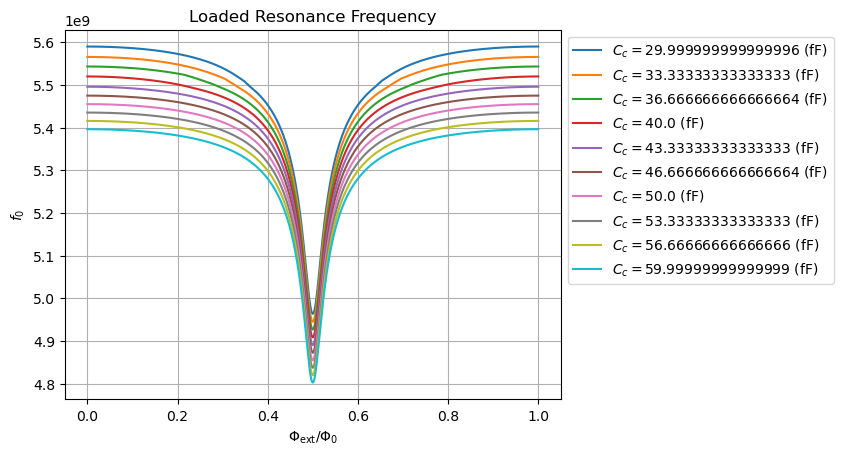

In [32]:
for i in range(len(C_c_vals)):
    plt.plot(phi_ext/(2*np.pi), f0_array_Cc[:,i], label = f'$C_c = {C_c_vals[i]/1e-15}$ (fF)')
    
plt.xlabel(r'$\Phi_{\rm ext}/\Phi_0$')
plt.ylabel(r'$f_0$')
plt.title(r"Loaded Resonance Frequency")
plt.grid(True)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

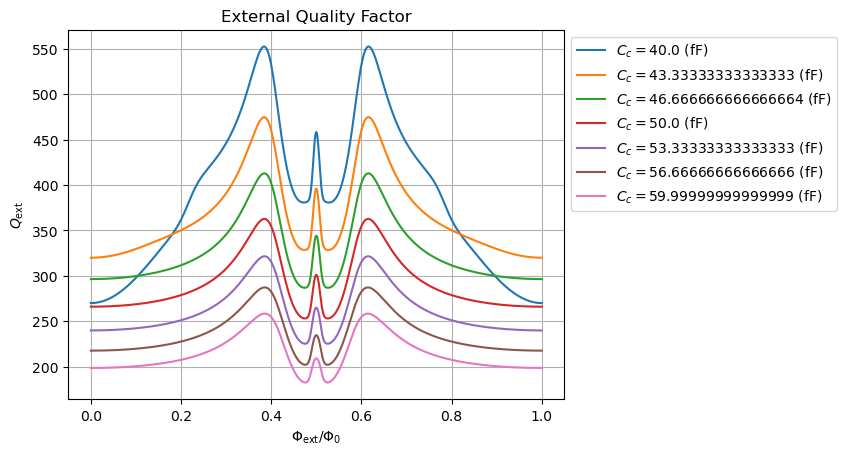

In [36]:
for i in range(len(C_c_vals)):
    if i > 2:
         plt.plot(phi_ext/(2*np.pi), q_external_array_Cc[:,i], label = f'$C_c = {C_c_vals[i]/1e-15}$ (fF)')
    
plt.xlabel(r'$\Phi_{\rm ext}/\Phi_0$')
plt.ylabel(r'$Q_{\rm ext}$')
plt.title(r"External Quality Factor")
plt.grid(True)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

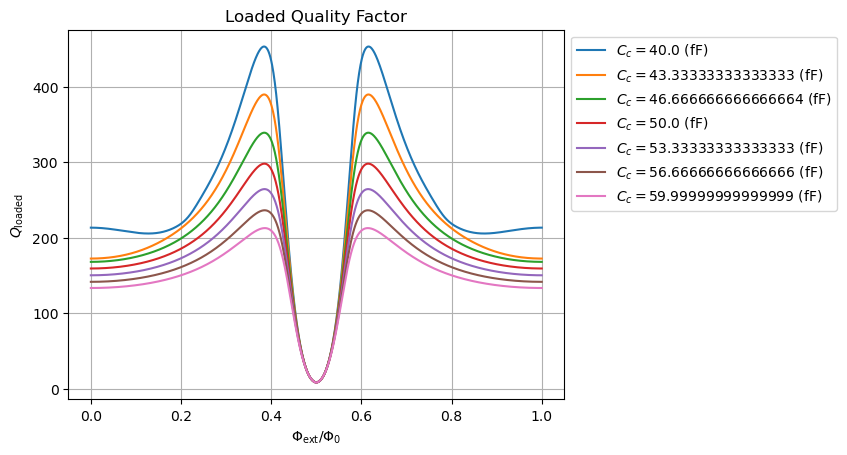

In [51]:
for i in range(len(C_c_vals)):
    if i > 2:
         plt.plot(phi_ext/(2*np.pi), q_loaded_array_Cc[:,i], label = f'$C_c = {C_c_vals[i]/1e-15}$ (fF)')
    
plt.xlabel(r'$\Phi_{\rm ext}/\Phi_0$')
plt.ylabel(r'$Q_{\rm loaded}$')
plt.title(r"Loaded Quality Factor")
plt.grid(True)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()